# Module 5: Model Development

## Input contract

Attach the saved output of `data_reconcile.ipynb`. This notebook loads only:

- `data_reconciled_after_fe.csv`
- `reconciliation_metadata.json`

It starts at feature selection and preserves the original model-development implementation unless a change is required for the new reconciled data lineage. Outcome columns are retained only for profiling and are never candidate clustering features.


In [1]:
import json
import shutil
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
KEY_COLS = ["id_student", "code_module", "code_presentation"]
OUTCOME_ONLY_COLUMNS = ["final_result", "final_result_encoded", "passed"]

WORK_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
INPUT_ROOT = Path("/kaggle/input")
OUTPUT_DIR = WORK_ROOT / "artifacts"
REPORT_DIR = WORK_ROOT / "reports"
FIGURE_DIR = WORK_ROOT / "figures"

for path in [OUTPUT_DIR, REPORT_DIR, FIGURE_DIR]:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

VARIANCE_THRESHOLD = 0.01
CORRELATION_THRESHOLD = 0.95
REMOVE_OUTLIERS_FOR_MODEL = True
OUTLIER_CONTAMINATION = 0.05
K_RANGE = range(2, 11)


def discover_unique_file(filename):
    roots = [INPUT_ROOT, Path.cwd(), Path("/mnt/data")]
    matches = []
    for root in roots:
        if root.exists():
            matches.extend(path for path in root.rglob(filename) if path.is_file())
    matches = sorted(set(path.resolve() for path in matches))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename}. Attach the saved output of data_reconcile.ipynb."
        )
    if len(matches) > 1:
        raise RuntimeError(
            f"Found multiple copies of {filename}:\n"
            + "\n".join(str(path) for path in matches)
            + "\nAttach only the intended data-reconcile output."
        )
    return matches[0]


data_path = discover_unique_file("data_reconciled_after_fe.csv")
reconciliation_metadata_path = discover_unique_file(
    "reconciliation_metadata.json"
)

feature_df = pd.read_csv(data_path)
with reconciliation_metadata_path.open(encoding="utf-8") as file:
    reconciliation_metadata = json.load(file)

print("Reconciled data:", data_path)
print("Reconciliation metadata:", reconciliation_metadata_path)
print("Shape:", feature_df.shape)


Reconciled data: /kaggle/input/notebooks/bachtruonggia/notebook110bd9d060/data_reconcile/artifacts/data_reconciled_after_fe.csv
Reconciliation metadata: /kaggle/input/notebooks/bachtruonggia/notebook110bd9d060/data_reconcile/artifacts/reconciliation_metadata.json
Shape: (32593, 53)


In [2]:
missing_keys = [column for column in KEY_COLS if column not in feature_df]
if missing_keys:
    raise ValueError(f"Missing key columns: {missing_keys}")
if feature_df.duplicated(KEY_COLS).any():
    raise ValueError("Reconciled data contain duplicate learner-course-presentation keys")
if "final_result" not in feature_df:
    raise ValueError("final_result is required for post-cluster profiling")

metadata_output = reconciliation_metadata.get("output", {})
if metadata_output.get("rows") != len(feature_df):
    raise ValueError("Reconciliation metadata row count does not match the CSV")
if metadata_output.get("columns") != feature_df.shape[1]:
    raise ValueError("Reconciliation metadata column count does not match the CSV")

base_behavior_features = [
    "login_weekly",
    "video_completion_rate",
    "forum_posts_count",
    "days_to_first_filled",
    "submission_timeliness_days",
    "never_started",
    "missed_submission",
    "late_submitter",
    "prompt_starter",
    "low_engagement_flag",
    "early_start_score",
    "frequency_score",
    "intensity_score",
    "forum_per_login",
    "completion_x_frequency",
    "procrastination_score",
    "engagement_breadth",
    "registration_delay_days",
    "registered_before_start",
]

vle_features = [
    column for column in [
        "vle_total_clicks",
        "vle_active_days",
        "vle_distinct_sites",
        "log_vle_total_clicks",
        "log_vle_active_days",
        "log_vle_distinct_sites",
        "clicks_per_active_day",
        "log_clicks_per_active_day",
        "vle_activity_type_diversity",
    ]
    if column in feature_df.columns
]

preferred_vle_ratios = [
    column for column in [
        "vle_clicks_forumng_ratio",
        "vle_clicks_resource_ratio",
        "vle_clicks_oucontent_ratio",
        "vle_clicks_quiz_ratio",
        "vle_clicks_homepage_ratio",
        "vle_clicks_subpage_ratio",
        "vle_clicks_url_ratio",
    ]
    if column in feature_df.columns
]

assessment_features = [
    column for column in [
        "assess_n_submitted",
        "assess_mean_score",
        "assess_n_banked",
        "assess_mean_days_before_deadline",
        "assess_n_late",
        "assessment_completion_rate",
        "late_assessment_rate",
        "assignment_timeliness_score",
    ]
    if column in feature_df.columns
]

login_time_features = [
    column for column in feature_df.columns
    if column.startswith("login_time_")
]

candidate_features = []
for group in [
    base_behavior_features,
    vle_features,
    preferred_vle_ratios,
    assessment_features,
    login_time_features,
]:
    for column in group:
        if column in feature_df.columns and column not in candidate_features:
            candidate_features.append(column)

leakage = sorted(set(candidate_features).intersection(OUTCOME_ONLY_COLUMNS))
if leakage:
    raise ValueError(f"Outcome leakage in clustering candidates: {leakage}")

missing_candidates = [
    column for column in base_behavior_features
    if column not in feature_df.columns
]
if missing_candidates:
    raise ValueError(f"Missing required behavioral features: {missing_candidates}")

feature_df[candidate_features] = feature_df[candidate_features].replace(
    [np.inf, -np.inf], np.nan
)
for column in candidate_features:
    if not pd.api.types.is_numeric_dtype(feature_df[column]):
        raise ValueError(f"Candidate feature is not numeric: {column}")
    feature_df[column] = feature_df[column].fillna(
        feature_df[column].median()
    )

if not np.isfinite(feature_df[candidate_features].to_numpy(dtype=float)).all():
    raise ValueError("Candidate features contain missing or infinite values")

before_rows = len(feature_df)
after_rows = len(feature_df)

raw_candidate_path = OUTPUT_DIR / "engineered_features_raw.csv"
profile_outcomes = [
    column for column in OUTCOME_ONLY_COLUMNS
    if column in feature_df.columns
]
feature_df[
    KEY_COLS + candidate_features + profile_outcomes
].to_csv(raw_candidate_path, index=False)

feature_overview = pd.DataFrame({
    "feature": candidate_features,
    "mean": feature_df[candidate_features].mean().round(4).values,
    "std": feature_df[candidate_features].std().round(4).values,
    "missing_pct": (
        feature_df[candidate_features].isna().mean().mul(100).round(2).values
    ),
    "n_unique": feature_df[candidate_features].nunique().values,
})

print("Validated reconciled model input.")
print("Rows:", len(feature_df))
print("Candidate features:", len(candidate_features))
print("Outcome-only columns:", profile_outcomes)
print("Saved compatibility artifact:", raw_candidate_path)
display(feature_overview)


Validated reconciled model input.
Rows: 32593
Candidate features: 47
Outcome-only columns: ['final_result', 'final_result_encoded', 'passed']
Saved compatibility artifact: /kaggle/working/artifacts/engineered_features_raw.csv


,feature,mean,std,missing_pct,n_unique
0,login_weekly,2.5998,3.4147,0.0,15
1,video_completion_rate,0.4445,0.3600,0.0,1001
2,forum_posts_count,1.4352,2.4489,0.0,11
3,days_to_first_filled,21.5603,29.8476,0.0,91
4,submission_timeliness_days,0.3621,3.1722,0.0,222
5,never_started,0.1391,0.3461,0.0,2
6,missed_submission,0.2160,0.4115,0.0,2
7,late_submitter,0.0167,0.1280,0.0,2
8,prompt_starter,0.5135,0.4998,0.0,2
9,low_engagement_flag,0.2178,0.4128,0.0,2


## 1. Feature selection and outlier handling

The following cells are split from the original combined notebook. They now operate on the reconciled Kaggle input.


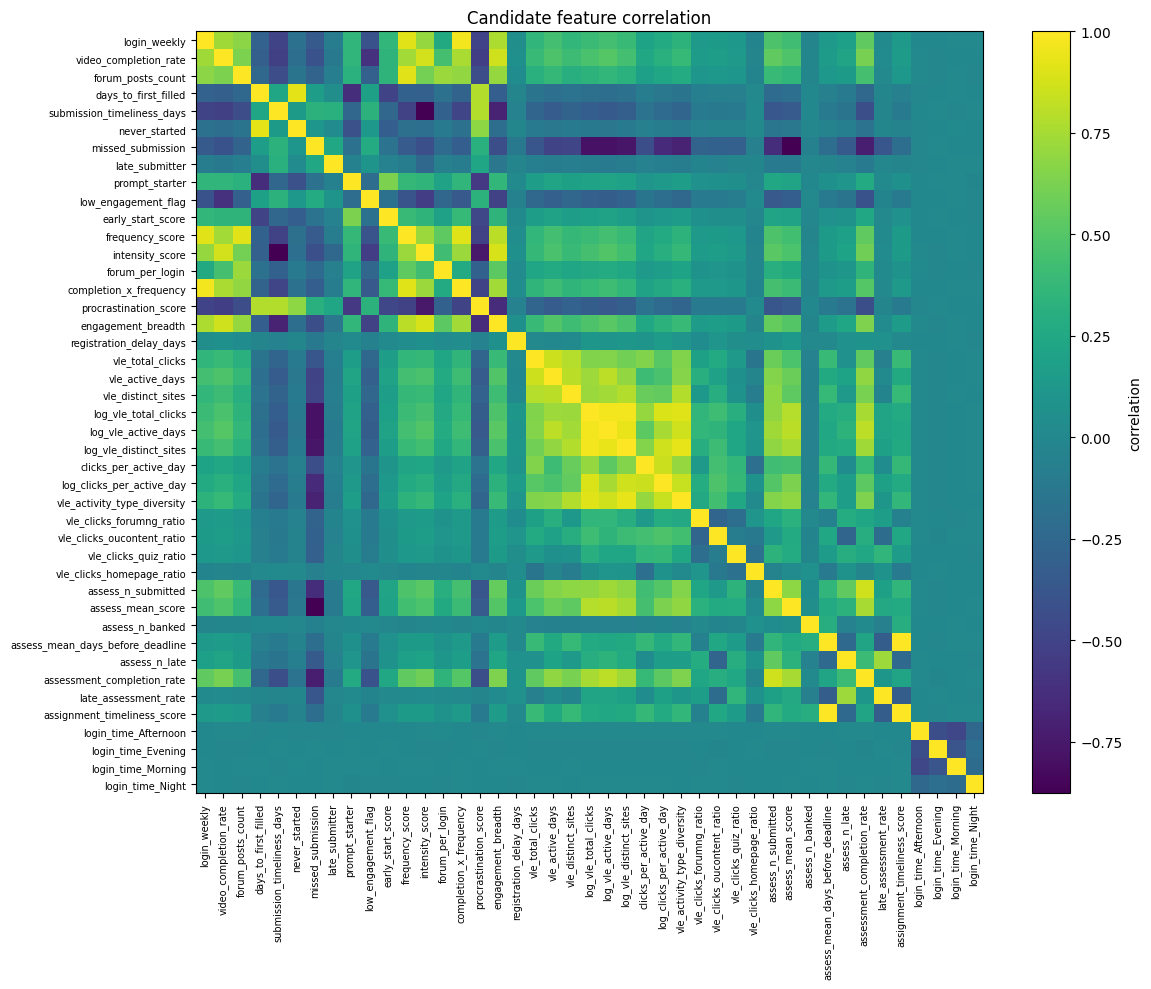

Dropped low variance: ['registered_before_start', 'vle_clicks_resource_ratio', 'vle_clicks_subpage_ratio', 'vle_clicks_url_ratio']
Dropped high correlation: ['completion_x_frequency', 'log_vle_active_days', 'log_vle_distinct_sites', 'assignment_timeliness_score']
Selected features: 39


,feature,selected,dropped_low_variance,dropped_high_corr
0,login_weekly,True,False,False
1,video_completion_rate,True,False,False
2,forum_posts_count,True,False,False
3,days_to_first_filled,True,False,False
4,submission_timeliness_days,True,False,False
5,never_started,True,False,False
6,missed_submission,True,False,False
7,late_submitter,True,False,False
8,prompt_starter,True,False,False
9,low_engagement_flag,True,False,False


In [3]:
variance_selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
variance_selector.fit(feature_df[candidate_features])

kept_by_variance = [
    c for c, keep in zip(candidate_features, variance_selector.get_support())
    if keep
]
dropped_low_variance = [c for c in candidate_features if c not in kept_by_variance]

corr_matrix = feature_df[kept_by_variance].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
dropped_high_corr = [c for c in upper.columns if any(upper[c] > CORRELATION_THRESHOLD)]

selected_features = [
    c for c in kept_by_variance
    if c not in dropped_high_corr
]

selection_report = pd.DataFrame({
    "feature": candidate_features,
    "selected": [c in selected_features for c in candidate_features],
    "dropped_low_variance": [c in dropped_low_variance for c in candidate_features],
    "dropped_high_corr": [c in dropped_high_corr for c in candidate_features],
})
selection_report.to_csv(REPORT_DIR / "feature_selection_report.csv", index=False)

plt.figure(figsize=(12, 10))
plt.imshow(feature_df[kept_by_variance].corr(), aspect="auto")
plt.colorbar(label="correlation")
plt.xticks(range(len(kept_by_variance)), kept_by_variance, rotation=90, fontsize=7)
plt.yticks(range(len(kept_by_variance)), kept_by_variance, fontsize=7)
plt.title("Candidate feature correlation")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "candidate_feature_correlation.png", dpi=150)
plt.show()

print("Dropped low variance:", dropped_low_variance or "none")
print("Dropped high correlation:", dropped_high_corr or "none")
print("Selected features:", len(selected_features))
display(selection_report)

In [4]:
model_source = feature_df[KEY_COLS + selected_features + ["final_result"]].copy()

outlier_scaler = StandardScaler()
outlier_X = outlier_scaler.fit_transform(model_source[selected_features])

outlier_model = IsolationForest(
    contamination=OUTLIER_CONTAMINATION,
    random_state=RANDOM_STATE,
)
model_source["outlier_flag"] = (outlier_model.fit_predict(outlier_X) == -1).astype(int)

outlier_audit = pd.crosstab(
    model_source["final_result"],
    model_source["outlier_flag"],
    normalize="index",
).round(3)

if REMOVE_OUTLIERS_FOR_MODEL:
    model_df = model_source[model_source["outlier_flag"] == 0].drop(columns="outlier_flag").reset_index(drop=True)
else:
    model_df = model_source.drop(columns="outlier_flag").reset_index(drop=True)

clustering_features_path = OUTPUT_DIR / "clustering_features.csv"
metadata_path = OUTPUT_DIR / "student_metadata.csv"

model_df[KEY_COLS + selected_features].to_csv(clustering_features_path, index=False)
model_df[KEY_COLS + ["final_result"]].to_csv(metadata_path, index=False)
outlier_audit.to_csv(REPORT_DIR / "outlier_audit_by_final_result.csv")

print("Rows before outlier handling:", len(model_source))
print("Rows for modeling:", len(model_df))
print("Outliers flagged:", int(model_source["outlier_flag"].sum()))
display(outlier_audit)
print("Saved:", clustering_features_path)
print("Saved:", metadata_path)

Rows before outlier handling: 32593
Rows for modeling: 30963
Outliers flagged: 1630


outlier_flag,0,1
final_result,,
Distinction,0.895,0.105
Fail,0.947,0.053
Pass,0.950,0.050
Withdrawn,0.968,0.032


Saved: /kaggle/working/artifacts/clustering_features.csv
Saved: /kaggle/working/artifacts/student_metadata.csv


### Outlier-handling decision

Isolation Forest flags the most unusual 5% of multivariate learner profiles before clustering. This is a modelling sensitivity assumption, not a claim that these learners are erroneous. The audit shows a higher flagged rate among `Distinction` learners, so extreme high-engagement behavior may also be affected. The excluded rows are retained in the audit artifacts, and the limitation should be reported when interpreting personas. The final clustering model uses the filtered reference to reduce centroid distortion from extreme profiles.

In [5]:
compact_features = [
    "login_weekly",
    "video_completion_rate",
    "forum_posts_count",
    "days_to_first_filled",
    "submission_timeliness_days",
    "never_started",
    "missed_submission",
]

compact_features = [c for c in compact_features if c in model_df.columns]

feature_sets = {
    "compact_behavior": compact_features,
    "engineered_selected": selected_features,
}

for name, cols in feature_sets.items():
    print(name, len(cols), cols)

profile_only_cols = [
    c for c in [
        "final_result",
        "final_result_encoded",
        "passed",
        "dominant_login_time",
        "gender",
        "region",
        "highest_education",
        "imd_band",
        "age_band",
        "num_of_prev_attempts",
        "studied_credits",
        "disability",
        "date_unregistration",
        "vle_total_clicks",
        "vle_active_days",
        "vle_distinct_sites",
        "assess_n_submitted",
        "assess_mean_score",
        "assess_mean_days_before_deadline",
        "assess_n_late",
    ]
    if c in feature_df.columns
]

profile_df = model_df[KEY_COLS + ["final_result"]].merge(
    feature_df[KEY_COLS + profile_only_cols],
    on=KEY_COLS,
    how="left",
    suffixes=("", "_profile"),
)

if "final_result_profile" in profile_df.columns:
    profile_df["final_result"] = profile_df["final_result"].fillna(profile_df["final_result_profile"])
    profile_df = profile_df.drop(columns=["final_result_profile"])

display(profile_df.head())

compact_behavior 7 ['login_weekly', 'video_completion_rate', 'forum_posts_count', 'days_to_first_filled', 'submission_timeliness_days', 'never_started', 'missed_submission']
engineered_selected 39 ['login_weekly', 'video_completion_rate', 'forum_posts_count', 'days_to_first_filled', 'submission_timeliness_days', 'never_started', 'missed_submission', 'late_submitter', 'prompt_starter', 'low_engagement_flag', 'early_start_score', 'frequency_score', 'intensity_score', 'forum_per_login', 'procrastination_score', 'engagement_breadth', 'registration_delay_days', 'vle_total_clicks', 'vle_active_days', 'vle_distinct_sites', 'log_vle_total_clicks', 'clicks_per_active_day', 'log_clicks_per_active_day', 'vle_activity_type_diversity', 'vle_clicks_forumng_ratio', 'vle_clicks_oucontent_ratio', 'vle_clicks_quiz_ratio', 'vle_clicks_homepage_ratio', 'assess_n_submitted', 'assess_mean_score', 'assess_n_banked', 'assess_mean_days_before_deadline', 'assess_n_late', 'assessment_completion_rate', 'late_asse

,id_student,code_module,code_presentation,final_result,final_result_encoded,passed,vle_total_clicks,vle_active_days,vle_distinct_sites,assess_n_submitted,assess_mean_score,assess_mean_days_before_deadline,assess_n_late
0,11391,AAA,2013J,Pass,2,1,934.0,40.0,55.0,5.0,82.0,1.8,0.0
1,28400,AAA,2013J,Pass,2,1,1435.0,80.0,84.0,5.0,66.4,0.0,2.0
2,30268,AAA,2013J,Withdrawn,0,0,281.0,12.0,22.0,0.0,0.0,0.0,0.0
3,31604,AAA,2013J,Pass,2,1,2158.0,123.0,82.0,5.0,76.0,2.0,0.0
4,32885,AAA,2013J,Pass,2,1,1034.0,70.0,66.0,5.0,54.4,-11.4,5.0


## 2. Clustering model development

K-Means, Hierarchical Clustering, and DBSCAN are evaluated exactly as in the original combined notebook. K-Means remains the deployable final estimator.


In [6]:
def evaluate_kmeans_for_features(data, features, k_range=K_RANGE):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data[features])

    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels = model.fit_predict(X_scaled)
        rows.append({
            "feature_set": None,
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        })

    return pd.DataFrame(rows), scaler, X_scaled


feature_set_results = []
scaled_cache = {}

for name, cols in feature_sets.items():
    result, scaler, X_scaled = evaluate_kmeans_for_features(model_df, cols)
    result["feature_set"] = name
    feature_set_results.append(result)
    scaled_cache[name] = {"scaler": scaler, "X_scaled": X_scaled}

feature_set_results = pd.concat(feature_set_results, ignore_index=True)
feature_set_summary = (
    feature_set_results
    .sort_values(["silhouette", "calinski_harabasz"], ascending=[False, False])
    .reset_index(drop=True)
)

display(feature_set_summary)

final_feature_set_name = "engineered_selected"
FEATURES = feature_sets[final_feature_set_name]
scaler = scaled_cache[final_feature_set_name]["scaler"]
X_scaled = scaled_cache[final_feature_set_name]["X_scaled"]
X = model_df[FEATURES].copy()

print("Final feature set:", final_feature_set_name)
print("Number of features:", len(FEATURES))

,feature_set,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,compact_behavior,4,70650.466822,0.397990,0.900744,21338.979445
1,compact_behavior,3,93526.097248,0.393607,0.983124,20393.989151
2,compact_behavior,6,52722.055074,0.370560,0.994754,19261.536313
3,compact_behavior,5,58219.055161,0.370033,0.996613,21073.593940
4,compact_behavior,2,143312.749255,0.317691,1.236541,15863.317031
5,compact_behavior,7,48439.120579,0.314575,1.066279,17926.268679
6,compact_behavior,9,41551.657917,0.309503,1.124094,16313.591003
7,compact_behavior,8,44803.603508,0.304268,1.179144,16970.379428
8,compact_behavior,10,38563.772771,0.289182,1.168167,15890.422723
9,engineered_selected,2,941361.209068,0.196955,1.827600,8755.075916


Final feature set: engineered_selected
Number of features: 39


### Feature-set and cluster-count decision

The compact seven-feature representation produces tighter geometric clusters, with its best silhouette near **0.398 at \(k=4\)**. The 39-feature engineered representation is intentionally retained because it captures the broader behavioral dimensions required for actionable learner personas: VLE activity composition, assessment completion, timeliness, login pattern, engagement breadth, and performance.

Within the engineered representation, \(k=2\) has the highest silhouette (**about 0.197**), while \(k=3\) is lower (**about 0.160**). The project retains \(k=3\) as a business–analytics trade-off rather than claiming it is the numerical optimum: it separates disengaged, moderate, and high-engagement learners into three operationally useful groups, keeps the smallest cluster near 21%, and avoids the increasingly fragmented groups observed for larger \(k\). The later stability and persona checks are therefore required to validate this choice.

Variance explained by 2 PCs: [0.305 0.097] | cumulative: 0.402


,PC1,PC2
assessment_completion_rate,0.246522,0.063774
log_vle_total_clicks,0.242629,0.240826
engagement_breadth,0.236803,-0.194597
assess_n_submitted,0.231800,0.095468
intensity_score,0.229874,-0.201996
assess_mean_score,0.225504,0.153517
video_completion_rate,0.225211,-0.172680
vle_activity_type_diversity,0.219921,0.261880
vle_active_days,0.216199,0.114988
frequency_score,0.214178,-0.219843


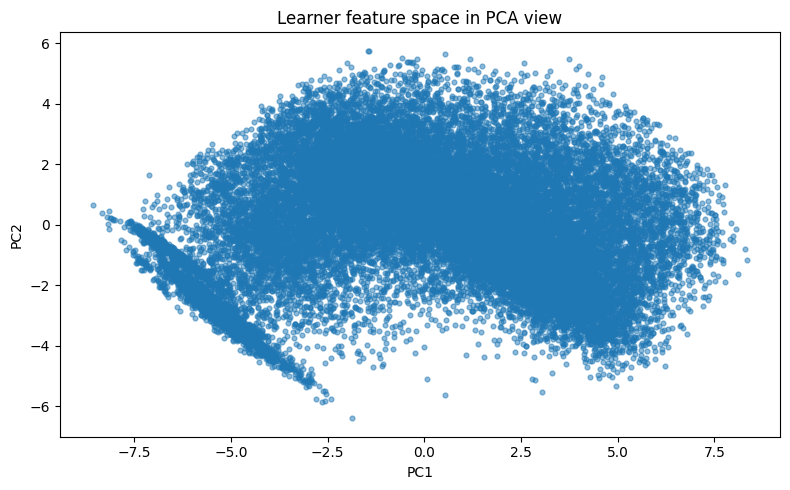

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(
    "Variance explained by 2 PCs:",
    np.round(pca.explained_variance_ratio_, 3),
    "| cumulative:",
    round(float(pca.explained_variance_ratio_.sum()), 3),
)

pca_loadings = pd.DataFrame(
    pca.components_,
    columns=FEATURES,
    index=["PC1", "PC2"],
).T.sort_values("PC1", key=lambda s: s.abs(), ascending=False)

display(pca_loadings.head(15))

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=12, alpha=0.5)
plt.title("Learner feature space in PCA view")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_feature_space.png", dpi=150)
plt.show()

,model,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_pct
0,K-Means,2,941361.2091,0.1970,1.8276,8755.0759,48.5870
1,K-Means,3,838417.7773,0.1600,2.0018,6815.5479,21.0348
2,K-Means,4,796196.9450,0.1390,2.1649,5331.7196,12.8670
3,K-Means,5,755271.8772,0.1397,2.1221,4634.7053,9.3854
4,K-Means,6,723672.2261,0.1384,2.1673,4139.8917,9.4015
5,K-Means,7,696092.9926,0.1260,2.0441,3790.8982,1.0432
6,K-Means,8,667623.0083,0.1261,2.0798,3576.3707,1.0432
7,K-Means,9,642709.3127,0.1356,1.8908,3400.5089,0.8171
8,K-Means,10,621313.7590,0.1278,1.9274,3245.0959,0.8171


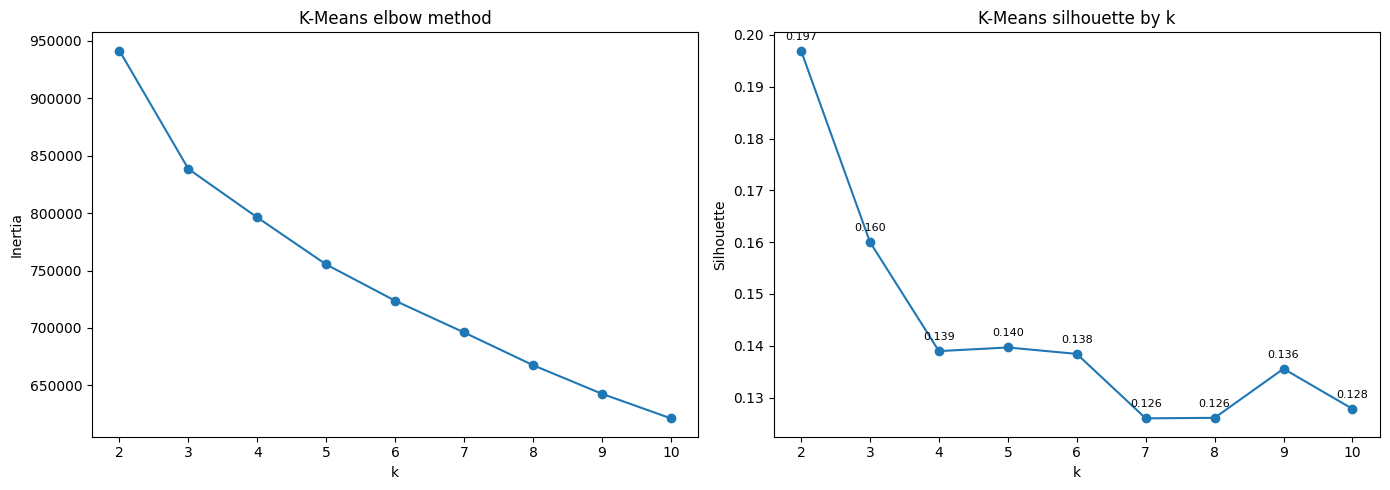

Chosen K: 3


In [8]:
kmeans_results = []

for k in K_RANGE:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    labels = model.fit_predict(X_scaled)
    kmeans_results.append({
        "model": "K-Means",
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "min_cluster_pct": pd.Series(labels).value_counts(normalize=True).min() * 100,
    })

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(kmeans_results["k"], kmeans_results["inertia"], "o-")
ax[0].set_title("K-Means elbow method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(kmeans_results["k"], kmeans_results["silhouette"], "o-")
ax[1].set_title("K-Means silhouette by k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
for _, row in kmeans_results.iterrows():
    ax[1].annotate(
        f"{row['silhouette']:.3f}",
        (row["k"], row["silhouette"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_elbow_silhouette.png", dpi=150)
plt.show()

K = int(kmeans_results.loc[kmeans_results["silhouette"].idxmax(), "k"])
if K < 3:
    K = int(
        kmeans_results
        .query("k >= 3")
        .sort_values("silhouette", ascending=False)
        .iloc[0]["k"]
    )

print("Chosen K:", K)

K-Means silhouette = 0.1600
Cluster sizes: {0: 12303, 1: 6513, 2: 12147}


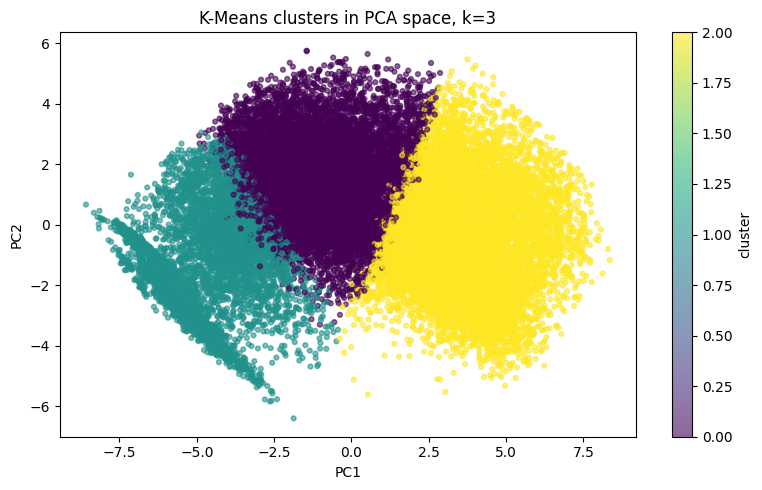

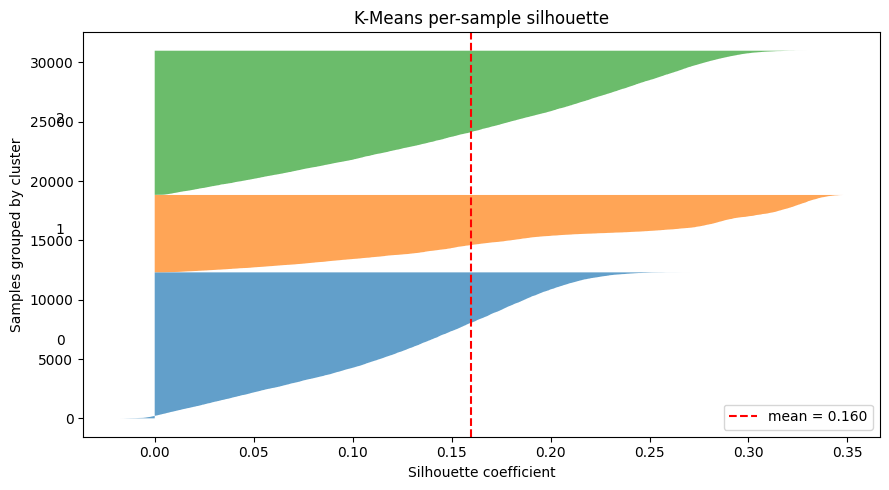

In [9]:
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=50)
km_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)

print(f"K-Means silhouette = {km_sil:.4f}")
print("Cluster sizes:", pd.Series(km_labels).value_counts().sort_index().to_dict())

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, s=12, alpha=0.6)
plt.title(f"K-Means clusters in PCA space, k={K}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_pca_clusters.png", dpi=150)
plt.show()

sample_sil = silhouette_samples(X_scaled, km_labels)
y_lower = 10
plt.figure(figsize=(9, 5))
for cluster_id in range(K):
    vals = np.sort(sample_sil[km_labels == cluster_id])
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * len(vals), str(cluster_id))
    y_lower = y_upper + 10

plt.axvline(km_sil, color="red", linestyle="--", label=f"mean = {km_sil:.3f}")
plt.title("K-Means per-sample silhouette")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Samples grouped by cluster")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_silhouette_diagnostic.png", dpi=150)
plt.show()

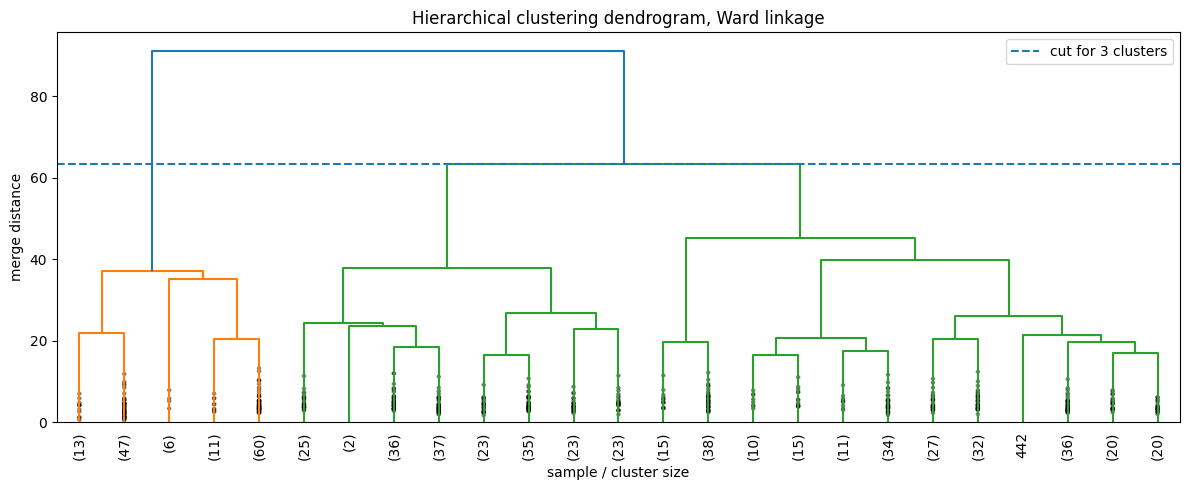

,model,k,silhouette,davies_bouldin,calinski_harabasz,min_cluster_pct
0,Hierarchical,2,0.2121,1.6388,6905.6976,21.6161
1,Hierarchical,3,0.1239,2.3659,5525.4463,21.6161
2,Hierarchical,4,0.1161,2.2855,4375.0070,7.8771
3,Hierarchical,5,0.1076,2.3474,3762.9816,7.8771
4,Hierarchical,6,0.1170,2.0964,3393.2153,1.0432
5,Hierarchical,7,0.1190,1.9447,3118.6289,1.0432
6,Hierarchical,8,0.1271,1.9155,2933.5237,1.0432
7,Hierarchical,9,0.1141,2.0134,2769.9550,1.0432
8,Hierarchical,10,0.1008,2.1418,2644.2625,1.0432


Hierarchical silhouette at K=3: 0.1239
Cluster sizes: {0: 11448, 1: 6693, 2: 12822}


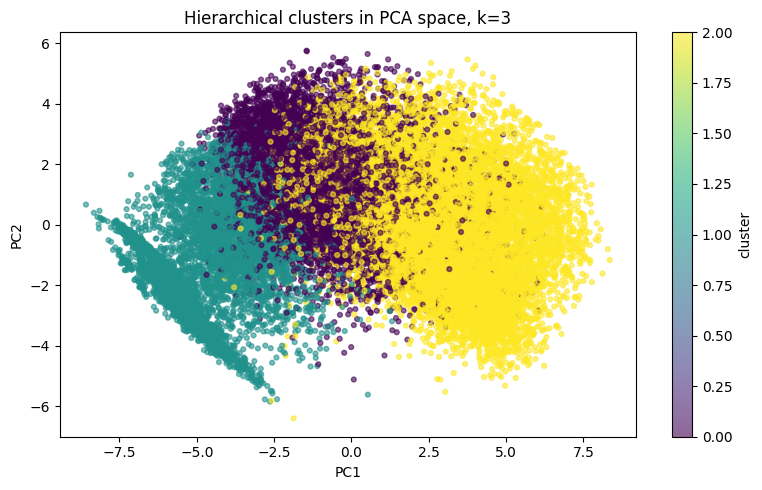

In [10]:
sample_size = min(600, len(X_scaled))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=sample_size, replace=False)
Z = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90, show_contracted=True)
plt.axhline(y=Z[-(K - 1), 2], linestyle="--", label=f"cut for {K} clusters")
plt.title("Hierarchical clustering dendrogram, Ward linkage")
plt.xlabel("sample / cluster size")
plt.ylabel("merge distance")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hierarchical_dendrogram.png", dpi=150)
plt.show()

hier_results = []
for k in K_RANGE:
    agg_model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg_model.fit_predict(X_scaled)
    hier_results.append({
        "model": "Hierarchical",
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "min_cluster_pct": pd.Series(labels).value_counts(normalize=True).min() * 100,
    })

hier_results = pd.DataFrame(hier_results)
display(hier_results.round(4))

agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)
agg_sil = silhouette_score(X_scaled, agg_labels)

print(f"Hierarchical silhouette at K={K}: {agg_sil:.4f}")
print("Cluster sizes:", pd.Series(agg_labels).value_counts().sort_index().to_dict())

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, s=12, alpha=0.6)
plt.title(f"Hierarchical clusters in PCA space, k={K}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hierarchical_pca_clusters.png", dpi=150)
plt.show()

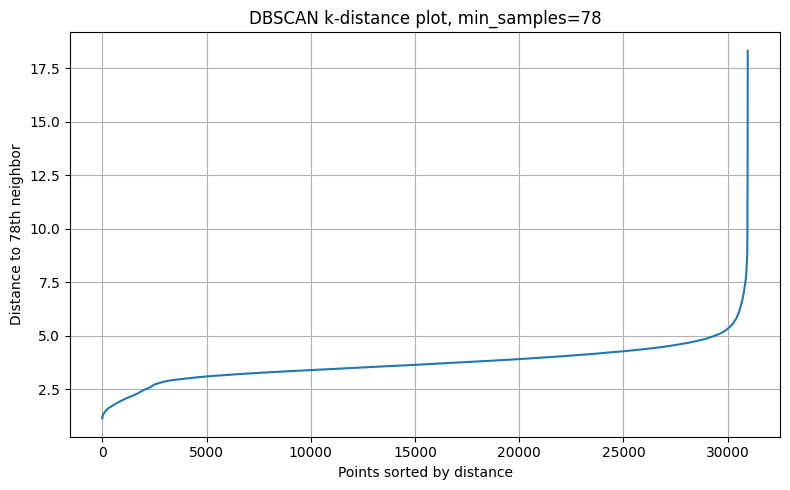

,model,eps,min_samples,n_clusters,noise_rate,silhouette_excluding_noise,davies_bouldin_excluding_noise,calinski_harabasz_excluding_noise
0,DBSCAN,4.013,78,1,0.0478,NaN,NaN,NaN
1,DBSCAN,4.124,78,2,0.0367,0.3975,0.6933,349.3390
2,DBSCAN,4.251,78,2,0.0288,0.3990,0.7233,471.2719
3,DBSCAN,4.407,78,2,0.0234,0.3986,0.7464,538.6940
4,DBSCAN,4.625,78,2,0.0193,0.3955,0.7705,593.7657
5,DBSCAN,4.742,78,2,0.0155,0.3851,0.8646,810.0379
6,DBSCAN,5.018,78,2,0.0116,0.3815,0.9083,1023.4108
7,DBSCAN,5.350,78,2,0.0096,0.3807,0.9263,1085.9412


Chosen DBSCAN eps: 4.251
DBSCAN clusters: 2; noise: 893 (2.9%)
DBSCAN silhouette excluding noise: 0.399


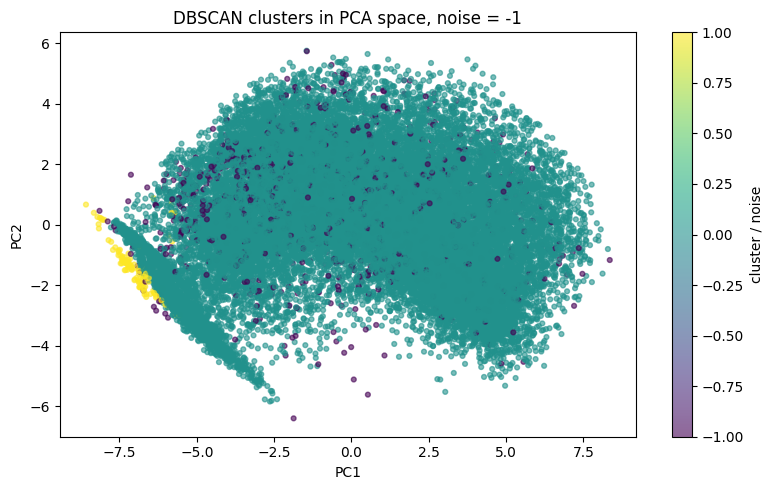

In [11]:
min_samples = max(5, 2 * len(FEATURES))
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f"DBSCAN k-distance plot, min_samples={min_samples}")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th neighbor")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dbscan_k_distance.png", dpi=150)
plt.show()

eps_grid = np.unique(np.round(np.percentile(k_distances, [70, 75, 80, 85, 90, 92, 95, 97]), 3))
dbscan_rows = []

for eps in eps_grid:
    db_model = DBSCAN(eps=float(eps), min_samples=min_samples)
    labels = db_model.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = float((labels == -1).mean())

    mask = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X_scaled[mask], labels[mask])
        dbi = davies_bouldin_score(X_scaled[mask], labels[mask])
        ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
    else:
        sil, dbi, ch = np.nan, np.nan, np.nan

    dbscan_rows.append({
        "model": "DBSCAN",
        "eps": float(eps),
        "min_samples": int(min_samples),
        "n_clusters": int(n_clusters),
        "noise_rate": noise_rate,
        "silhouette_excluding_noise": sil,
        "davies_bouldin_excluding_noise": dbi,
        "calinski_harabasz_excluding_noise": ch,
    })

dbscan_results = pd.DataFrame(dbscan_rows)
display(dbscan_results.round(4))

valid_dbscan = dbscan_results.query("n_clusters >= 2").copy()
if len(valid_dbscan):
    chosen_dbscan_row = valid_dbscan.sort_values(
        ["silhouette_excluding_noise", "noise_rate"],
        ascending=[False, True],
    ).iloc[0]
else:
    chosen_dbscan_row = dbscan_results.iloc[0]

dbscan = DBSCAN(
    eps=float(chosen_dbscan_row["eps"]),
    min_samples=int(chosen_dbscan_row["min_samples"]),
)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
db_mask = db_labels != -1

if n_clusters_db >= 2 and db_mask.sum() > n_clusters_db:
    db_sil = silhouette_score(X_scaled[db_mask], db_labels[db_mask])
else:
    db_sil = np.nan

print("Chosen DBSCAN eps:", float(chosen_dbscan_row["eps"]))
print(f"DBSCAN clusters: {n_clusters_db}; noise: {n_noise} ({n_noise / len(db_labels):.1%})")
print("DBSCAN silhouette excluding noise:", None if pd.isna(db_sil) else round(float(db_sil), 4))

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, s=12, alpha=0.6)
plt.title("DBSCAN clusters in PCA space, noise = -1")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster / noise")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dbscan_pca_clusters.png", dpi=150)
plt.show()

In [12]:
def score_partition(name, labels, allow_noise=False):
    mask = labels != -1 if allow_noise else np.ones(len(labels), dtype=bool)
    label_subset = labels[mask]
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if len(set(label_subset)) < 2:
        return {
            "model": name,
            "n_clusters": n_clusters,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
            "noise_rate": float((labels == -1).mean()) if allow_noise else 0.0,
        }

    return {
        "model": name,
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X_scaled[mask], label_subset),
        "davies_bouldin": davies_bouldin_score(X_scaled[mask], label_subset),
        "calinski_harabasz": calinski_harabasz_score(X_scaled[mask], label_subset),
        "noise_rate": float((labels == -1).mean()) if allow_noise else 0.0,
    }


comparison = pd.DataFrame([
    score_partition("K-Means", km_labels),
    score_partition("Hierarchical", agg_labels),
    score_partition("DBSCAN", db_labels, allow_noise=True),
]).round(4)

ari_km_agg = adjusted_rand_score(km_labels, agg_labels)

comparison.to_csv(REPORT_DIR / "model_comparison.csv", index=False)
kmeans_results.to_csv(REPORT_DIR / "kmeans_k_scan.csv", index=False)
hier_results.to_csv(REPORT_DIR / "hierarchical_k_scan.csv", index=False)
dbscan_results.to_csv(REPORT_DIR / "dbscan_eps_scan.csv", index=False)

display(comparison)
print(f"Adjusted Rand Index, K-Means vs Hierarchical = {ari_km_agg:.4f}")

FINAL_MODEL_NAME = "K-Means"
final_estimator = kmeans
final_labels = km_labels

work = model_df[KEY_COLS + FEATURES + ["final_result"]].copy()
work["cluster"] = final_labels

print("Final model:", FINAL_MODEL_NAME)
display(work["cluster"].value_counts().sort_index().rename("cluster_size"))

,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_rate
0,K-Means,3,0.1600,2.0018,6815.5479,0.0000
1,Hierarchical,3,0.1239,2.3659,5525.4463,0.0000
2,DBSCAN,2,0.3990,0.7233,471.2719,0.0288


Adjusted Rand Index, K-Means vs Hierarchical = 0.5517
Final model: K-Means


cluster
0    12303
1     6513
2    12147
Name: cluster_size, dtype: int64

,check,mean,std,min,max
0,random_seed_pairwise_ari,0.9992,0.0004,0.9982,0.9999
1,bootstrap_ari,0.9959,0.0020,0.9891,0.9980


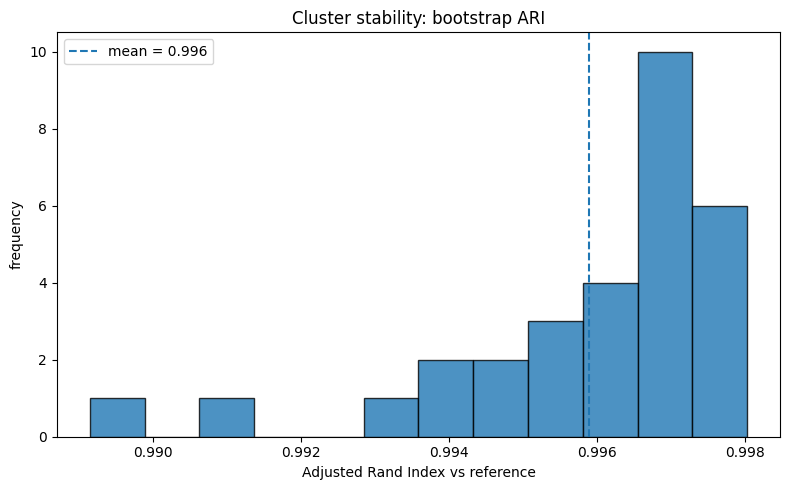

In [13]:
def kmeans_seed_stability(X_arr, k, seeds):
    labels_list = []
    for seed in seeds:
        labels = KMeans(n_clusters=k, random_state=seed, n_init=30).fit_predict(X_arr)
        labels_list.append(labels)

    scores = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            scores.append(adjusted_rand_score(labels_list[i], labels_list[j]))

    return np.array(scores)


def bootstrap_stability(X_arr, k, n_iter=30, sample_frac=0.8, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    ref = KMeans(n_clusters=k, random_state=seed, n_init=30).fit_predict(X_arr)
    aris = []
    n = len(X_arr)

    for _ in range(n_iter):
        idx = rng.choice(n, size=int(sample_frac * n), replace=False)
        labels = KMeans(
            n_clusters=k,
            random_state=int(rng.randint(1_000_000)),
            n_init=30,
        ).fit_predict(X_arr[idx])
        aris.append(adjusted_rand_score(ref[idx], labels))

    return np.array(aris)


seed_aris = kmeans_seed_stability(X_scaled, K, seeds=[1, 2, 3, 4, 5, 42, 100])
boot_aris = bootstrap_stability(X_scaled, K, n_iter=30)

stability_summary = pd.DataFrame([
    {
        "check": "random_seed_pairwise_ari",
        "mean": seed_aris.mean(),
        "std": seed_aris.std(),
        "min": seed_aris.min(),
        "max": seed_aris.max(),
    },
    {
        "check": "bootstrap_ari",
        "mean": boot_aris.mean(),
        "std": boot_aris.std(),
        "min": boot_aris.min(),
        "max": boot_aris.max(),
    },
]).round(4)

stability_summary.to_csv(REPORT_DIR / "cluster_stability_summary.csv", index=False)

display(stability_summary)

plt.figure(figsize=(8, 5))
plt.hist(boot_aris, bins=12, edgecolor="black", alpha=0.8)
plt.axvline(boot_aris.mean(), linestyle="--", label=f"mean = {boot_aris.mean():.3f}")
plt.title("Cluster stability: bootstrap ARI")
plt.xlabel("Adjusted Rand Index vs reference")
plt.ylabel("frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_stability_bootstrap_ari.png", dpi=150)
plt.show()

### Final model decision

DBSCAN reports the highest silhouette (**about 0.399**) only after excluding its noise points and produces two density groups, so its score is not directly comparable with the three-cluster full-sample K-Means result. It also has no native `predict()` method for assigning a new learner. Hierarchical clustering is useful as a structural comparison but likewise does not provide a simple production assignment rule.

K-Means is selected for deployment because it:

- assigns incoming learners directly through saved scaler and centroid artifacts;
- produces three balanced and interpretable personas;
- supports centroid and segment-share monitoring;
- is highly reproducible in the subsequent seed and bootstrap checks.

The choice prioritizes deployability, stability, and business usefulness alongside—not solely—the silhouette score.

In [14]:
profile_work = work.merge(profile_df, on=KEY_COLS, how="left", suffixes=("", "_profile"))

numeric_profile_cols = []
for col in FEATURES + [
    "vle_total_clicks",
    "vle_active_days",
    "vle_distinct_sites",
    "assess_n_submitted",
    "assess_mean_score",
    "assess_mean_days_before_deadline",
    "assess_n_late",
    "num_of_prev_attempts",
    "studied_credits",
]:
    if col in profile_work.columns and pd.api.types.is_numeric_dtype(profile_work[col]) and col not in numeric_profile_cols:
        numeric_profile_cols.append(col)

cluster_profile = profile_work.groupby("cluster")[numeric_profile_cols].mean().round(3)
cluster_profile["size"] = profile_work.groupby("cluster").size()
cluster_profile["pct"] = (cluster_profile["size"] / len(profile_work) * 100).round(2)

final_result_by_cluster = pd.crosstab(
    profile_work["cluster"],
    profile_work["final_result"],
    normalize="index",
).round(3)

login_time_columns = [
    column for column in [
        "login_time_Afternoon",
        "login_time_Evening",
        "login_time_Morning",
        "login_time_Night",
    ]
    if column in profile_work.columns
]

if "dominant_login_time" not in profile_work.columns and login_time_columns:
    login_time_totals = profile_work[login_time_columns].sum(axis=1)
    if not np.allclose(login_time_totals, 1, atol=1e-10, rtol=0):
        raise ValueError("Login-time one-hot columns do not sum to one")
    profile_work["dominant_login_time"] = (
        profile_work[login_time_columns]
        .idxmax(axis=1)
        .str.replace("login_time_", "", regex=False)
    )

login_time_by_cluster = (
    pd.crosstab(
        profile_work["cluster"],
        profile_work["dominant_login_time"],
        normalize="index",
    ).round(3)
    if "dominant_login_time" in profile_work.columns
    else pd.DataFrame()
)

module_by_cluster = pd.crosstab(
    profile_work["cluster"],
    profile_work["code_module"],
    normalize="index",
).round(3)

cluster_profile.to_csv(REPORT_DIR / "cluster_profile_numeric.csv")
final_result_by_cluster.to_csv(REPORT_DIR / "cluster_final_result_distribution.csv")
login_time_by_cluster.to_csv(REPORT_DIR / "cluster_login_time_distribution.csv")
module_by_cluster.to_csv(REPORT_DIR / "cluster_module_distribution.csv")

display(cluster_profile)
display(final_result_by_cluster)
display(login_time_by_cluster)
display(module_by_cluster)

,login_weekly,video_completion_rate,forum_posts_count,days_to_first_filled,submission_timeliness_days,never_started,missed_submission,late_submitter,prompt_starter,low_engagement_flag,early_start_score,frequency_score,intensity_score,forum_per_login,procrastination_score,engagement_breadth,registration_delay_days,vle_total_clicks,vle_active_days,vle_distinct_sites,log_vle_total_clicks,clicks_per_active_day,log_clicks_per_active_day,vle_activity_type_diversity,vle_clicks_forumng_ratio,vle_clicks_oucontent_ratio,vle_clicks_quiz_ratio,vle_clicks_homepage_ratio,assess_n_submitted,assess_mean_score,assess_n_banked,assess_mean_days_before_deadline,assess_n_late,assessment_completion_rate,late_assessment_rate,login_time_Afternoon,login_time_Evening,login_time_Morning,login_time_Night,size,pct
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.705,0.244,0.144,28.340,1.472,0.186,0.024,0.006,0.355,0.312,0.130,-1.082,-0.907,0.067,0.577,0.835,-65.518,777.813,42.950,51.694,6.156,17.853,2.820,7.962,0.174,0.228,0.169,0.219,4.734,65.935,0.078,7.388,1.682,0.545,0.356,0.343,0.259,0.299,0.099,12303,39.73
1,0.300,0.156,0.064,30.357,2.179,0.201,0.974,0.039,0.343,0.446,0.128,-1.233,-1.376,0.033,0.868,0.462,-81.640,34.491,2.768,6.120,1.742,5.620,1.126,2.391,0.056,0.092,0.023,0.191,0.050,1.531,0.013,0.288,0.006,0.006,0.004,0.344,0.259,0.302,0.096,6513,21.03
2,5.536,0.788,3.251,6.694,-1.706,0.015,0.001,0.000,0.783,0.001,0.318,1.601,1.606,0.568,-1.150,3.382,-66.430,1994.177,91.059,91.544,7.232,20.600,2.970,9.235,0.190,0.262,0.174,0.194,8.479,78.118,0.027,14.321,2.088,0.943,0.235,0.366,0.239,0.300,0.095,12147,39.23


final_result,Distinction,Fail,Pass,Withdrawn
cluster,,,,
0,0.004,0.376,0.254,0.365
1,0.000,0.186,0.000,0.814
2,0.219,0.069,0.709,0.004


dominant_login_time,Afternoon,Evening,Morning,Night
cluster,,,,
0,0.343,0.259,0.299,0.099
1,0.344,0.259,0.302,0.096
2,0.366,0.239,0.300,0.095


code_module,AAA,BBB,CCC,DDD,EEE,FFF,GGG
cluster,,,,,,,
0,0.025,0.239,0.159,0.213,0.081,0.210,0.073
1,0.006,0.285,0.150,0.201,0.084,0.207,0.067
2,0.031,0.231,0.103,0.176,0.108,0.256,0.095


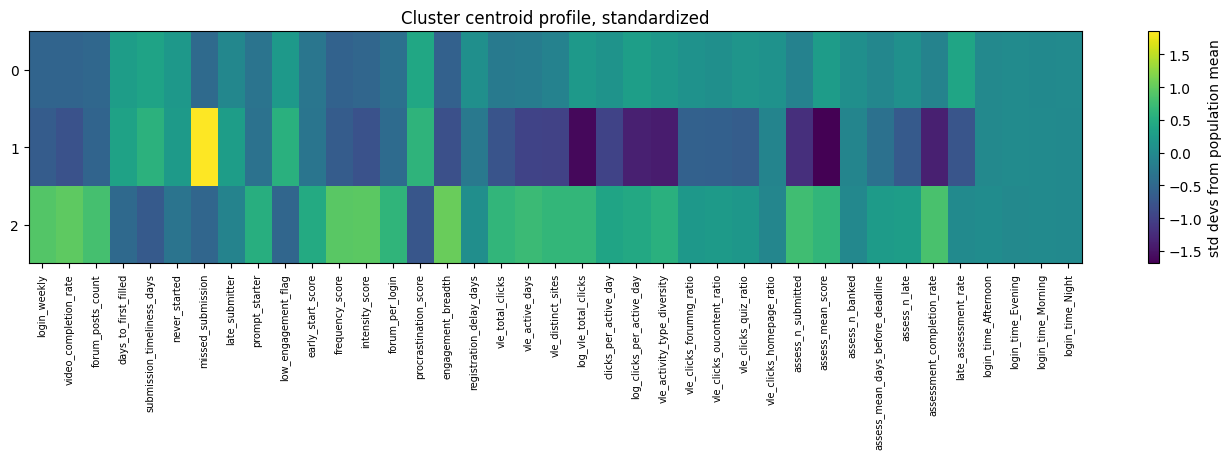

,login_weekly,video_completion_rate,forum_posts_count,days_to_first_filled,submission_timeliness_days,never_started,missed_submission,late_submitter,prompt_starter,low_engagement_flag,early_start_score,frequency_score,intensity_score,forum_per_login,procrastination_score,engagement_breadth,registration_delay_days,vle_total_clicks,vle_active_days,vle_distinct_sites,log_vle_total_clicks,clicks_per_active_day,log_clicks_per_active_day,vle_activity_type_diversity,vle_clicks_forumng_ratio,vle_clicks_oucontent_ratio,vle_clicks_quiz_ratio,vle_clicks_homepage_ratio,assess_n_submitted,assess_mean_score,assess_n_banked,assess_mean_days_before_deadline,assess_n_late,assessment_completion_rate,late_assessment_rate,login_time_Afternoon,login_time_Evening,login_time_Morning,login_time_Night
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.54,-0.54,-0.51,0.28,0.36,0.20,-0.47,-0.05,-0.33,0.23,-0.30,-0.58,-0.52,-0.38,0.41,-0.59,0.08,-0.23,-0.20,-0.12,0.21,0.14,0.29,0.19,0.11,0.08,0.16,0.11,-0.11,0.27,0.08,-0.05,0.09,-0.10,0.39,-0.02,0.02,-0.0,0.01
1,-0.66,-0.79,-0.54,0.35,0.59,0.24,1.85,0.28,-0.36,0.55,-0.31,-0.66,-0.80,-0.45,0.61,-0.83,-0.25,-0.76,-0.98,-0.99,-1.60,-0.97,-1.38,-1.42,-0.59,-0.61,-0.65,-0.09,-1.21,-1.69,-0.07,-0.37,-0.68,-1.37,-0.75,-0.02,0.02,0.0,-0.00
2,0.91,0.98,0.81,-0.48,-0.68,-0.33,-0.52,-0.10,0.53,-0.53,0.47,0.94,0.95,0.63,-0.74,1.04,0.06,0.64,0.73,0.65,0.65,0.38,0.44,0.56,0.20,0.25,0.19,-0.07,0.76,0.64,-0.04,0.25,0.28,0.84,0.00,0.03,-0.03,0.0,-0.01


In [15]:
centroid_raw = profile_work.groupby("cluster")[FEATURES].mean()
centroid_z = (centroid_raw - profile_work[FEATURES].mean()) / profile_work[FEATURES].std()
centroid_z = centroid_z.replace([np.inf, -np.inf], 0).fillna(0)

plt.figure(figsize=(max(12, len(FEATURES) * 0.35), 0.9 * K + 2))
plt.imshow(centroid_z, aspect="auto")
plt.colorbar(label="std devs from population mean")
plt.xticks(range(len(centroid_z.columns)), centroid_z.columns, rotation=90, fontsize=7)
plt.yticks(range(len(centroid_z.index)), centroid_z.index)
plt.title("Cluster centroid profile, standardized")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_centroid_heatmap.png", dpi=150)
plt.show()

display(centroid_z.round(2))

,cluster,persona,size,pct,risk_level,description,recommendation
0,0,Steady Moderate,12303,39.73,Medium,Average learner profile with stable but not st...,Use light encouragement and next-best-content ...
1,1,At-Risk Disengaged,6513,21.03,High,Very low engagement or never-started behavior;...,"Tutor outreach, onboarding support, simplified..."
2,2,Consistent Achiever,12147,39.23,Low,High engagement and strong performance with re...,"Offer enrichment content, optional advanced ta..."


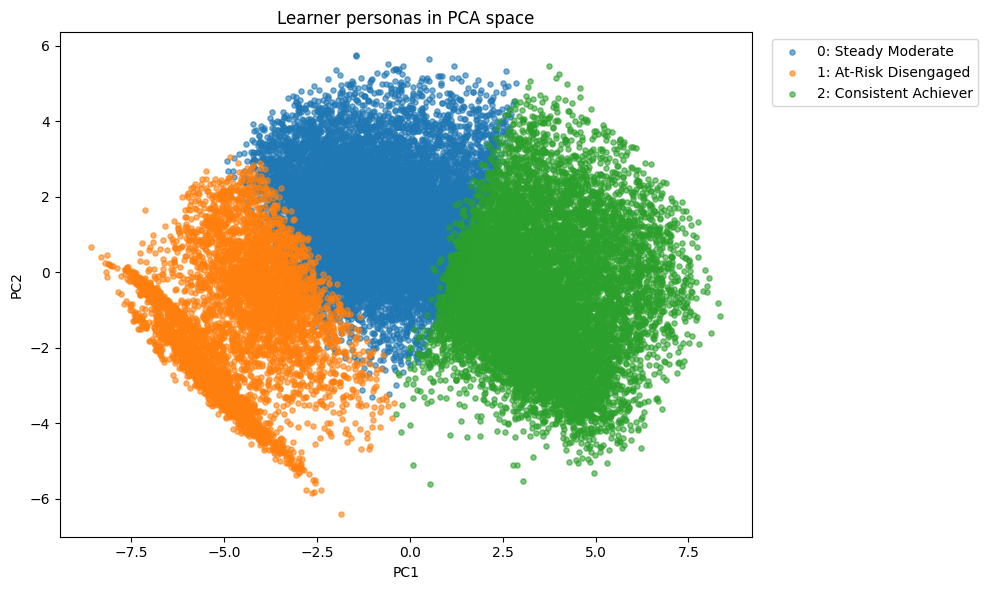

In [16]:
def z_mean(row, names):
    vals = [row[c] for c in names if c in row.index]
    return float(np.mean(vals)) if vals else 0.0


def persona_from_centroid(row):
    engagement = z_mean(row, [
        "login_weekly",
        "video_completion_rate",
        "forum_posts_count",
        "log_vle_total_clicks",
        "log_vle_active_days",
        "vle_activity_type_diversity",
    ])
    performance = z_mean(row, [
        "assess_mean_score",
        "assessment_completion_rate",
        "assignment_timeliness_score",
    ])
    delay = z_mean(row, [
        "days_to_first_filled",
        "procrastination_score",
        "submission_timeliness_days",
        "late_assessment_rate",
    ])
    risk = z_mean(row, [
        "never_started",
        "missed_submission",
        "low_engagement_flag",
    ])

    if risk > 0.6 and engagement < -0.2:
        return (
            "At-Risk Disengaged",
            "Very low engagement or never-started behavior; highest priority for proactive support.",
            "High",
            "Tutor outreach, onboarding support, simplified first tasks, and early-warning follow-up.",
        )

    if engagement > 0.45 and performance > 0.25 and delay < 0.4:
        return (
            "Consistent Achiever",
            "High engagement and strong performance with relatively healthy pacing.",
            "Low",
            "Offer enrichment content, optional advanced tasks, and peer-mentor opportunities.",
        )

    if engagement > 0.35 and performance < -0.25:
        return (
            "Active Struggler",
            "Learner is active but performance does not match effort.",
            "Medium-High",
            "Recommend remedial content, targeted quiz review, and instructor feedback.",
        )

    if delay > 0.45 and engagement > -0.25:
        return (
            "Last-Minute Crammer",
            "Engagement exists but timing is late or bursty around deadlines.",
            "Medium",
            "Use milestone reminders, calendar nudges, and smaller weekly pacing goals.",
        )

    if engagement < -0.35:
        return (
            "Passive Low-Engagement",
            "Below-average activity without enough evidence of steady learning behavior.",
            "Medium-High",
            "Send re-engagement messages, low-friction quick-win activities, and check-in prompts.",
        )

    return (
        "Steady Moderate",
        "Average learner profile with stable but not standout activity.",
        "Medium",
        "Use light encouragement and next-best-content recommendations.",
    )


persona_rows = []
used_names = {}

for cluster_id in sorted(centroid_z.index):
    persona, description, risk_level, recommendation = persona_from_centroid(centroid_z.loc[cluster_id])
    if persona in used_names:
        used_names[persona] += 1
        persona = f"{persona} {used_names[persona]}"
    else:
        used_names[persona] = 1

    persona_rows.append({
        "cluster": int(cluster_id),
        "persona": persona,
        "size": int(cluster_profile.loc[cluster_id, "size"]),
        "pct": float(cluster_profile.loc[cluster_id, "pct"]),
        "risk_level": risk_level,
        "description": description,
        "recommendation": recommendation,
    })

persona_summary = pd.DataFrame(persona_rows)
persona_map = dict(zip(persona_summary["cluster"], persona_summary["persona"]))

profile_work["persona"] = profile_work["cluster"].map(persona_map)
work["persona"] = work["cluster"].map(persona_map)

persona_summary.to_csv(REPORT_DIR / "persona_summary.csv", index=False)

display(persona_summary)

plt.figure(figsize=(10, 6))
for cluster_id in sorted(work["cluster"].unique()):
    mask = work["cluster"] == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=14,
        alpha=0.6,
        label=f"{cluster_id}: {persona_map[cluster_id]}",
    )

plt.title("Learner personas in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "persona_pca_scatter.png", dpi=150)
plt.show()

In [17]:
feature_list_path = OUTPUT_DIR / "selected_features.json"
metadata_json_path = OUTPUT_DIR / "model_metadata.json"
learner_segments_path = OUTPUT_DIR / "learners_with_segments.csv"

joblib.dump(scaler, OUTPUT_DIR / "scaler.joblib")
joblib.dump(final_estimator, OUTPUT_DIR / "kmeans_model.joblib")
joblib.dump(outlier_scaler, OUTPUT_DIR / "outlier_scaler.joblib")
joblib.dump(outlier_model, OUTPUT_DIR / "outlier_model.joblib")

with feature_list_path.open("w", encoding="utf-8") as file:
    json.dump(FEATURES, file, indent=2)

zscore_columns = [
    "login_weekly",
    "forum_posts_count",
    "video_completion_rate",
    "submission_timeliness_days",
    "days_to_first_filled",
]
preprocessing_state = {
    "days_to_first_median": float(feature_df["days_to_first_filled"].median()),
    "login_q25": float(feature_df["login_weekly"].quantile(0.25)),
    "video_q25": float(feature_df["video_completion_rate"].quantile(0.25)),
    "login_median": float(feature_df["login_weekly"].median()),
    "video_median": float(feature_df["video_completion_rate"].median()),
    "forum_median": float(feature_df["forum_posts_count"].median()),
    "timeliness_median": float(
        feature_df["submission_timeliness_days"].median()
    ),
    "zscore": {
        column: {
            "mean": float(feature_df[column].mean()),
            "std": float(feature_df[column].std(ddof=1)),
        }
        for column in zscore_columns
    },
}

assessment_max_submitted = {
    f"{module}|{presentation}": float(value)
    for (module, presentation), value in (
        feature_df.groupby(
            ["code_module", "code_presentation"]
        )["assess_n_submitted"].max().items()
    )
}

winsorization_caps = reconciliation_metadata.get(
    "winsorization_caps", {}
)
fractional_count_features = reconciliation_metadata.get(
    "fractional_count_features", []
)

metadata = {
    "model": FINAL_MODEL_NAME,
    "feature_set": final_feature_set_name,
    "k": int(K),
    "features": FEATURES,
    "n_model_rows": int(len(work)),
    "silhouette": float(km_sil),
    "hierarchical_silhouette_at_k": float(agg_sil),
    "dbscan_silhouette_excluding_noise": (
        None if pd.isna(db_sil) else float(db_sil)
    ),
    "ari_kmeans_hierarchical": float(ari_km_agg),
    "stability_seed_mean_ari": float(seed_aris.mean()),
    "stability_bootstrap_mean_ari": float(boot_aris.mean()),
    "persona_map": {str(key): value for key, value in persona_map.items()},
    "data_lineage": {
        "source_data": data_path.name,
        "reconciliation_metadata": reconciliation_metadata_path.name,
        "source_recleaned_filename": reconciliation_metadata.get(
            "source", {}
        ).get("filename"),
        "source_recleaned_sha256": reconciliation_metadata.get(
            "source", {}
        ).get("sha256"),
        "reconciliation_applied": True,
        "recomputed_features": reconciliation_metadata.get(
            "reconciliation", {}
        ).get("recomputed_features", []),
    },
    "outcome_columns_excluded_from_clustering": OUTCOME_ONLY_COLUMNS,
    "winsorization_caps": winsorization_caps,
    "fractional_count_features": fractional_count_features,
    "clicks_per_active_day_cap": reconciliation_metadata.get(
        "reconciliation", {}
    ).get("clicks_per_active_day_cap"),
    "preprocessing_state": preprocessing_state,
    "assessment_max_submitted": assessment_max_submitted,
}

with metadata_json_path.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

profile_work.to_csv(learner_segments_path, index=False)

model_input_report = {
    "source_data": data_path.name,
    "source_rows": int(len(feature_df)),
    "rows_for_model": int(len(model_df)),
    "candidate_features": candidate_features,
    "selected_features": selected_features,
    "dropped_low_variance": dropped_low_variance,
    "dropped_high_corr": dropped_high_corr,
    "remove_outliers_for_model": bool(REMOVE_OUTLIERS_FOR_MODEL),
    "outlier_contamination": float(OUTLIER_CONTAMINATION),
    "outcome_columns_excluded": OUTCOME_ONLY_COLUMNS,
    "reconciliation_applied": True,
}

with (REPORT_DIR / "module4_feature_engineering_summary.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(model_input_report, file, indent=2)

with (REPORT_DIR / "reconciliation_metadata_used.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(reconciliation_metadata, file, indent=2)

print("Saved artifacts:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path)

print("\nSaved reports:")
for path in sorted(REPORT_DIR.iterdir()):
    print(" -", path)

print("\nSaved figures:")
for path in sorted(FIGURE_DIR.iterdir()):
    print(" -", path)


Saved artifacts:
 - /kaggle/working/artifacts/clustering_features.csv
 - /kaggle/working/artifacts/engineered_features_raw.csv
 - /kaggle/working/artifacts/kmeans_model.joblib
 - /kaggle/working/artifacts/learners_with_segments.csv
 - /kaggle/working/artifacts/model_metadata.json
 - /kaggle/working/artifacts/outlier_model.joblib
 - /kaggle/working/artifacts/outlier_scaler.joblib
 - /kaggle/working/artifacts/scaler.joblib
 - /kaggle/working/artifacts/selected_features.json
 - /kaggle/working/artifacts/student_metadata.csv

Saved reports:
 - /kaggle/working/reports/cluster_final_result_distribution.csv
 - /kaggle/working/reports/cluster_login_time_distribution.csv
 - /kaggle/working/reports/cluster_module_distribution.csv
 - /kaggle/working/reports/cluster_profile_numeric.csv
 - /kaggle/working/reports/cluster_stability_summary.csv
 - /kaggle/working/reports/dbscan_eps_scan.csv
 - /kaggle/working/reports/feature_selection_report.csv
 - /kaggle/working/reports/hierarchical_k_scan.csv
 - /

## 3. Saved-artifact inference smoke test

This cell verifies that the reloaded scaler and K-Means model reproduce the assignment of a fully reconciled, contract-valid feature vector. It deliberately does not invent partially updated engineered features. A production API must transform a raw learner profile with the same preprocessing state stored in `model_metadata.json` before calling the model.

In [18]:
loaded_scaler = joblib.load(OUTPUT_DIR / "scaler.joblib")
loaded_model = joblib.load(OUTPUT_DIR / "kmeans_model.joblib")

# Use one fully reconciled, contract-valid feature vector to test the saved
# inference artifacts. Raw-profile-to-feature transformation belongs to the
# deployment preprocessing layer and must reuse the same saved metadata.
example_row = 0
incoming_profile = model_df.loc[[example_row], FEATURES].copy()

if list(incoming_profile.columns) != list(FEATURES):
    raise ValueError("Inference feature order does not match the saved contract")
if not np.isfinite(incoming_profile.to_numpy(dtype=float)).all():
    raise ValueError("Inference profile contains missing or infinite values")

login_time_columns = [
    column for column in [
        "login_time_Afternoon",
        "login_time_Evening",
        "login_time_Morning",
        "login_time_Night",
    ]
    if column in incoming_profile.columns
]
if login_time_columns and not np.allclose(
    incoming_profile[login_time_columns].sum(axis=1),
    1,
    atol=1e-10,
    rtol=0,
):
    raise ValueError("Inference login-time one-hot columns do not sum to one")

pred_cluster = int(
    loaded_model.predict(
        loaded_scaler.transform(incoming_profile[FEATURES])
    )[0]
)
pred_persona = persona_map[pred_cluster]
expected_cluster = int(work.loc[example_row, "cluster"])

if pred_cluster != expected_cluster:
    raise ValueError(
        "Reloaded artifacts do not reproduce the fitted model assignment"
    )

print("Saved-artifact inference smoke test passed.")
print("Assigned cluster:", pred_cluster)
print("Persona:", pred_persona)
display(incoming_profile[FEATURES])


Saved-artifact inference smoke test passed.
Assigned cluster: 2
Persona: Consistent Achiever


,login_weekly,video_completion_rate,forum_posts_count,days_to_first_filled,submission_timeliness_days,never_started,missed_submission,late_submitter,prompt_starter,low_engagement_flag,early_start_score,frequency_score,intensity_score,forum_per_login,procrastination_score,engagement_breadth,registration_delay_days,vle_total_clicks,vle_active_days,vle_distinct_sites,log_vle_total_clicks,clicks_per_active_day,log_clicks_per_active_day,vle_activity_type_diversity,vle_clicks_forumng_ratio,vle_clicks_oucontent_ratio,vle_clicks_quiz_ratio,vle_clicks_homepage_ratio,assess_n_submitted,assess_mean_score,assess_n_banked,assess_mean_days_before_deadline,assess_n_late,assessment_completion_rate,late_assessment_rate,login_time_Afternoon,login_time_Evening,login_time_Morning,login_time_Night
0,2,0.934,5,9.0,-0.2,0,0,0,0,0,0.1,1.280061,1.537005,1.666667,-0.597998,4,-159.0,934.0,40.0,55.0,6.840547,23.35,3.192532,6,0.206638,0.592077,0.0,0.147752,5.0,82.0,0.0,1.8,0.0,1.0,0.0,1,0,0,0


## Required successful output

Before connecting this notebook to monitoring, confirm that the saved Kaggle version contains at least:

- `artifacts/clustering_features.csv`
- `artifacts/selected_features.json`
- `artifacts/scaler.joblib`
- `artifacts/kmeans_model.joblib`
- `artifacts/model_metadata.json`
- `artifacts/outlier_scaler.joblib`
- `artifacts/outlier_model.joblib`

Do not attach an older model-development output at the same time, because monitoring intentionally fails on duplicate artifact names.
